In [1]:
# %% Imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import windows
import os
%matplotlib widget

plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)


In [2]:
data_dir = Path("~/eedm_jml/daqAnalysisAndExperiments/launch/measureTrackVelocityBeatNote/data_gitignore/10Shots_2026_may_15").expanduser()
#data_dir = Path("~/eedm_jml/daqAnalysisAndExperiments/launch/measureTrackVelocityBeatNote/data_gitignore/70mmps_2026_may_26").expanduser()
#data_dir = Path("~/eedm_jml/daqAnalysisAndExperiments/launch/measureTrackVelocityBeatNote/data_gitignore/").expanduser()
files = sorted(data_dir.glob("*.npz"))

if len(files) == 1:
    fname = files[0]
    print(f"One file found, using: {fname.name}")
elif len(files) == 0:
    raise FileNotFoundError(f"No .npz files in {data_dir}")
else:
    most_recent = max(files, key=lambda p: p.stat().st_mtime)
    print(f"{len(files)} files found. Most recent: {most_recent.name}")
    user_in = input("Enter filename (blank = most recent): ").strip()
    fname = data_dir / user_in if user_in else most_recent
    print(f"Using: {fname.name}")

d = np.load(fname, allow_pickle=True)
print("Keys:", list(d.keys()))

t = d["times"]
v = d["voltages"]
fs = float(d["sample_rate"])
xinc = 1.0 / fs

print(f"N = {len(v)},  fs = {fs/1e6:.1f} MSa/s,  duration = {len(v)*xinc*1e3:.2f} ms")
print(f"V range: {v.min()*1e3:.2f} to {v.max()*1e3:.2f} mV")

10 files found. Most recent: beat_20260515_180423.npz
Using: beat_20260515_180423.npz
Keys: ['times', 'voltages', 'sample_rate', 'timestamp']
N = 10000000,  fs = 10.0 MSa/s,  duration = 1000.00 ms
V range: -31.75 to 2.56 mV


Cut: 0.000 to 400.000 ms (4000000 pts, 400.00 ms)


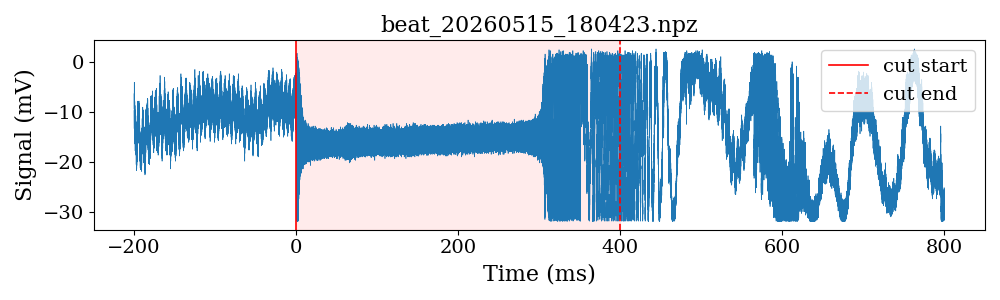

In [5]:
t_start = 0e-3      # seconds  <-- edit
t_end   = 400e-3    # seconds  <-- edit

# Clip to available range
t_start = max(t_start, t[0])
t_end   = min(t_end, t[-1])

i_start = np.searchsorted(t, t_start)
i_end   = np.searchsorted(t, t_end)
t_cut = t[i_start:i_end]
v_cut = v[i_start:i_end]
print(f"Cut: {t_start*1e3:.3f} to {t_end*1e3:.3f} ms ({len(v_cut)} pts, {len(v_cut)*xinc*1e3:.2f} ms)")

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t * 1e3, v * 1e3, lw=0.5)
ax.axvline(t_start * 1e3, color="r", lw=1.2, label="cut start")
ax.axvline(t_end   * 1e3, color="r", lw=1.2, ls="--", label="cut end")
ax.axvspan(t_start * 1e3, t_end * 1e3, color="r", alpha=0.08)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Signal (mV)")
ax.set_title(fname.name)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Waterfall: 400 segments x 5001 freq bins
Segment duration: 1.000 ms,  freq resolution: 1000.0 Hz


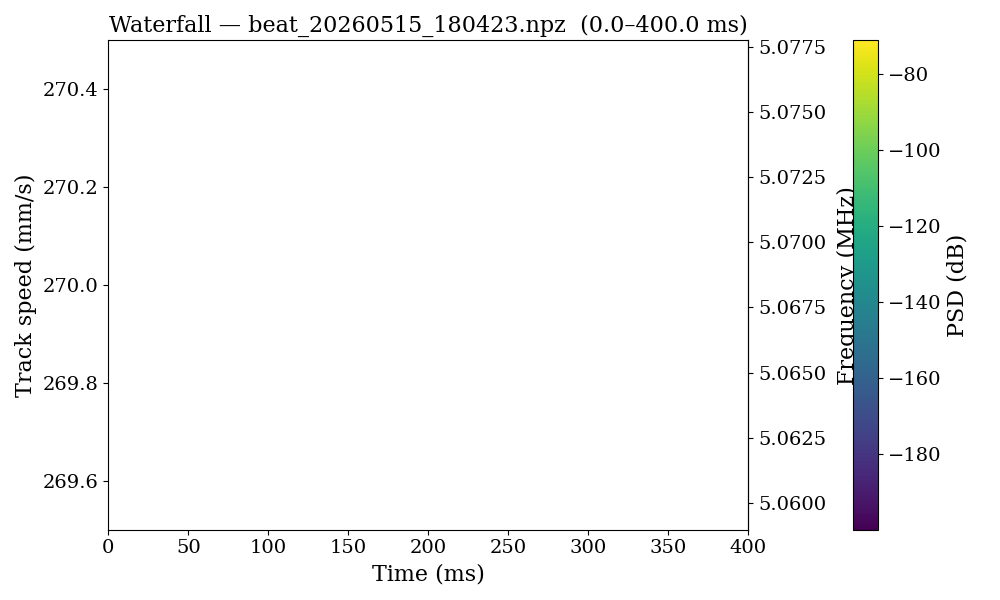

In [4]:
# %% Cell 3 — Waterfall on the cut data (time horizontal, velocity vertical)
seg_dur = 1e-3
overlap = 0
window_name = "hann"

nperseg = int(round(seg_dur / xinc))
nstep = int(round(nperseg * (1 - overlap)))
nseg = 1 + (len(v_cut) - nperseg) // nstep

if nseg < 1:
    raise ValueError(f"Cut region ({len(v_cut)*xinc*1e3:.2f} ms) shorter than segment ({seg_dur*1e3:.2f} ms)")

win = windows.get_window(window_name, nperseg)
win_norm = np.sum(win**2)

freqs = np.fft.rfftfreq(nperseg, d=xinc)
seg_times = t_cut[0] + (np.arange(nseg) * nstep + nperseg / 2) * xinc

spec = np.empty((nseg, len(freqs)), dtype=np.float32)
for i in range(nseg):
    chunk = v_cut[i*nstep : i*nstep + nperseg]
    chunk = (chunk - chunk.mean()) * win
    X = np.fft.rfft(chunk)
    psd = (np.abs(X)**2) / (fs * win_norm)
    psd[1:-1] *= 2
    spec[i] = psd

spec_db = 10 * np.log10(spec + 1e-20)
print(f"Waterfall: {nseg} segments x {len(freqs)} freq bins")
print(f"Segment duration: {seg_dur*1e3:.3f} ms,  freq resolution: {1/seg_dur:.1f} Hz")

WAVELENGTH = 852.34727582e-9   # m
N_BOUNCES  = 16                # 8 bounces, double-pass

def f_to_v(f_hz):
    return WAVELENGTH * f_hz / N_BOUNCES   # m/s

def v_to_f(v_ms):
    return N_BOUNCES * v_ms / WAVELENGTH   # Hz

# Plot with velocity (mm/s) on the primary y-axis
vels_mm = f_to_v(freqs) * 1e3   # mm/s

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(
    seg_times * 1e3,
    vels_mm,
    spec_db.T,
    shading="auto",
    cmap="viridis",
)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Track speed (mm/s)")
ax.set_title(f"Waterfall — {fname.name}  ({t_start*1e3:.1f}–{t_end*1e3:.1f} ms)")

# Secondary y-axis: frequency in MHz
secax = ax.secondary_yaxis(
    "right",
    functions=(
        lambda v_mm: v_to_f(v_mm * 1e-3) / 1e6,   # mm/s -> MHz
        lambda f_mhz: f_to_v(f_mhz * 1e6) * 1e3,  # MHz -> mm/s
    ),
)
secax.set_ylabel("Frequency (MHz)", labelpad=8)

# Colorbar placed with explicit padding so it sits clear of the right-side axis
cbar = fig.colorbar(im, ax=ax, label="PSD (dB)", pad=0.12)

# Optional zoom / clim
# ax.set_ylim(0, f_to_v(100e6)*1e3)
# im.set_clim(vmax=spec_db.max(), vmin=spec_db.max() - 60)
plt.ylim(269.5, 270.5)

plt.tight_layout()
plt.show()
plt.grid()

In [7]:
# %% Cell 3b — Single FFT slice from the waterfall
SLICE_TIME_MS = 100.0    # pick a time in ms; nearest segment is used
XLIM_MHZ      = None     # e.g. (3.7, 3.8); None = full range
YLIM_DB       = None     # e.g. (-120, -40); None = auto

# Find nearest segment
idx = int(np.argmin(np.abs(seg_times*1e3 - SLICE_TIME_MS)))
t_actual_ms = seg_times[idx] * 1e3
psd_db = spec_db[idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs/1e6, psd_db, lw=0.6, color="C0")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("PSD (dB)")
ax.set_title(f"FFT slice @ {t_actual_ms:.3f} ms  (segment {idx}/{nseg-1}) — {fname.name}")
ax.grid(True, alpha=0.3)
if XLIM_MHZ is not None: ax.set_xlim(XLIM_MHZ)
if YLIM_DB  is not None: ax.set_ylim(YLIM_DB)

# Match the secondary x-axis from the waterfall
secax = ax.secondary_xaxis(
    "top",
    functions=(
        lambda f_mhz: f_to_v(f_mhz * 1e6) * 1e3,   # MHz -> mm/s
        lambda v_mm:  v_to_f(v_mm * 1e-3) / 1e6,   # mm/s -> MHz
    ),
)
secax.set_xlabel("Track speed (mm/s)")

fig.tight_layout()
plt.show()

# Quick peak readout
peak_i = int(np.argmax(psd_db))
print(f"Peak: f = {freqs[peak_i]/1e6:.6f} MHz  =>  v = {f_to_v(freqs[peak_i])*1e3:.4f} mm/s "
      f"(PSD = {psd_db[peak_i]:.1f} dB)")

NameError: name 'seg_times' is not defined

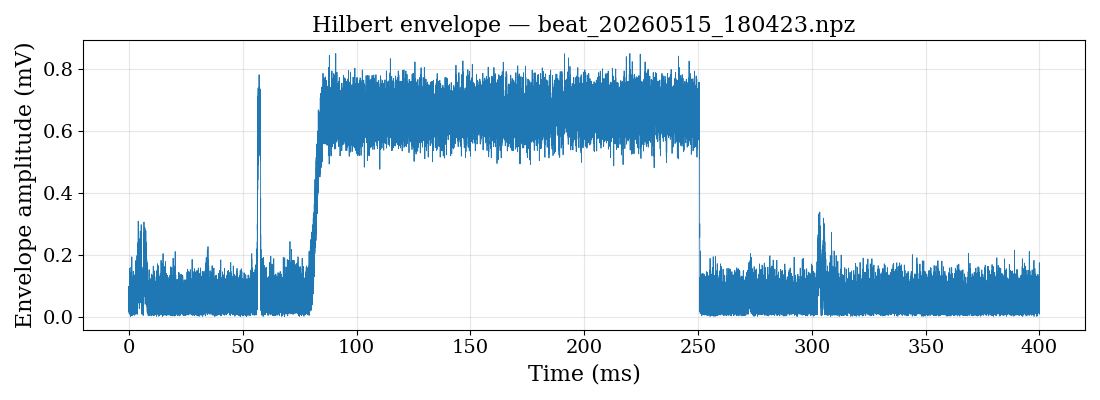

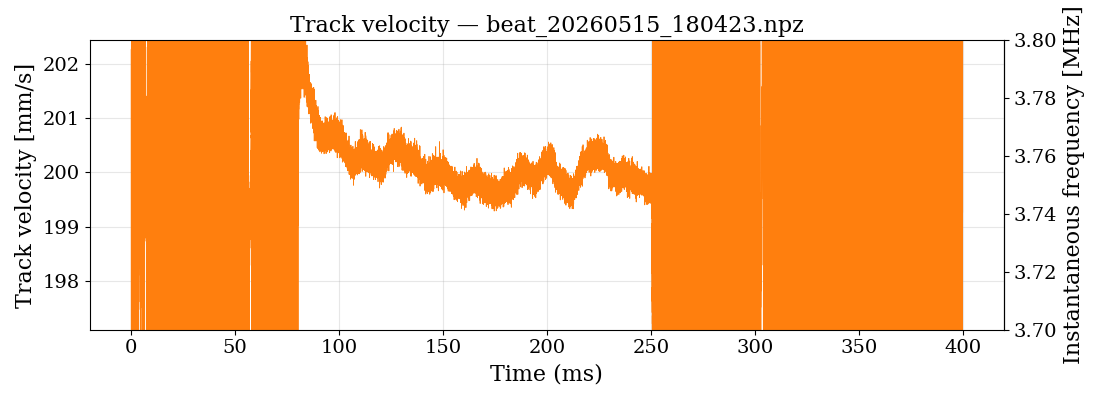

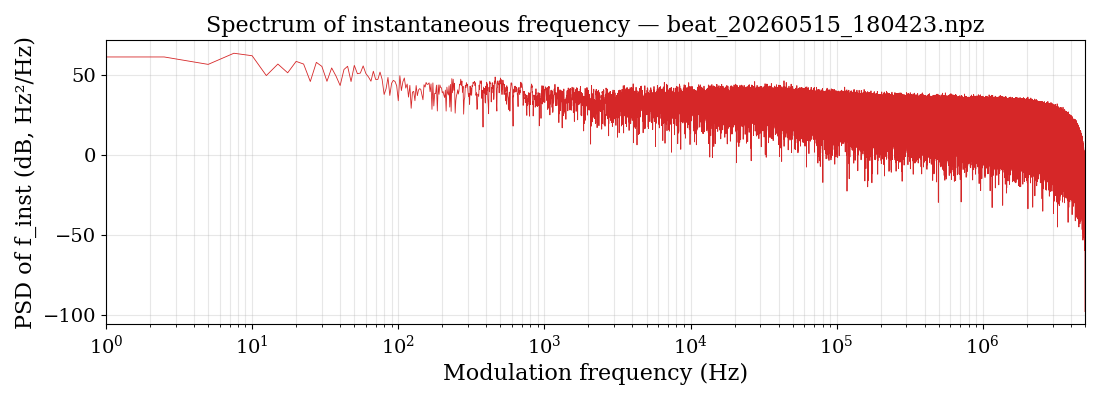

In [15]:
# %% Cell 4 — Hilbert envelope, instantaneous frequency, velocity
from scipy.signal import hilbert, butter, filtfilt
from scipy.ndimage import uniform_filter1d

# ---- Bandpass around the expected beat band ----
# Your signal lives roughly 0–4 MHz. Pick a band that excludes DC and the
# 2nd-harmonic ghost above ~3.6 MHz. Adjust as needed.
F_LO = 3.7e6 #* 70/200      # Hz, high-pass corner (kills DC drift / low-freq junk)
F_HI = 3.8e6 #* 70/200    # Hz, low-pass corner (kills the 4 MHz ghost)
ORDER = 4

nyq = fs / 2
b, a = butter(ORDER, [F_LO/nyq, F_HI/nyq], btype="band")
v_filt = filtfilt(b, a, v_cut)

# ---- Analytic signal ----
analytic = hilbert(v_filt)
envelope = np.abs(analytic)
phase = np.unwrap(np.angle(analytic))

# Instantaneous frequency via centered difference
f_inst = np.gradient(phase, xinc) / (2 * np.pi)   # Hz

# Optional: smooth f_inst a bit (rolling mean) to suppress phase noise.
# Window of ~1 ms is usually a good starting point.
SMOOTH_MS = 0
nsmooth = max(1, int(round(SMOOTH_MS * 1e-3 * fs)))
if nsmooth > 1:
    kernel = np.ones(nsmooth) / nsmooth
    f_inst_s = uniform_filter1d(f_inst, size=nsmooth, mode="nearest")
    env_s    = uniform_filter1d(envelope, size=nsmooth, mode="nearest")
else:
    f_inst_s = f_inst
    env_s    = envelope

# ---- Velocity ----
v_track = WAVELENGTH * f_inst_s / N_BOUNCES   # m/s

# Decimate for plotting (don't try to draw 10M points)
DECIM = max(1, len(t_cut) // 100000)
ts = t_cut[::DECIM] * 1e3   # ms

# %% Figure 1 — Hilbert envelope
plt.close('all')
fig1, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(ts, env_s[::DECIM] * 1e3, lw=0.6, color="C0")
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Envelope amplitude (mV)")
ax1.set_title(f"Hilbert envelope — {fname.name}")
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
plt.show()


fig2, ax2 = plt.subplots(figsize=(11, 4))
v_track_khz = f_to_v(f_inst_s) * 1e3   # m/s -> mm/s
ax2.plot(ts, v_track_khz[::DECIM], lw=0.6, color="C1")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Track velocity [mm/s]")
ax2.set_title(f"Track velocity — {fname.name}")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(f_to_v(F_LO) * 1e3, f_to_v(F_HI) * 1e3)



secax = ax2.secondary_yaxis(
    "right",
    functions=(
        lambda v_mm:  v_to_f(v_mm * 1e-3) / 1e6,   # mm/s -> MHz
        lambda f_mhz: f_to_v(f_mhz * 1e6) * 1e3,   # MHz -> mm/s
    ),
)
secax.set_ylabel("Instantaneous frequency [MHz]")

fig2.tight_layout()
plt.show()


# %% Figure 4 — FFT of instantaneous frequency
# Reveals periodic structure in the velocity (mechanical resonances,
# servo oscillations, mains pickup, encoder ripple, etc.)

# Use the unsmoothed f_inst so we don't roll off real high-frequency content.
# Detrend by removing the mean (and optionally a linear trend) so the DC
# component and the overall sweep don't dominate the spectrum.
from scipy.signal import detrend

f_for_fft = detrend(f_inst, type="linear")   # remove mean + linear sweep

# Window to control spectral leakage
N = len(f_for_fft)
win = np.hanning(N)
win_norm = np.sum(win**2)

F = np.fft.rfft(f_for_fft * win)
psd = (np.abs(F) ** 2) / (fs * win_norm)
psd[1:-1] *= 2
freqs_fft = np.fft.rfftfreq(N, d=xinc)

psd_db = 10 * np.log10(psd + 1e-30)

fig4, ax4 = plt.subplots(figsize=(11, 4))
ax4.semilogx(freqs_fft, psd_db, lw=0.6, color="C3")
ax4.set_xlabel("Modulation frequency (Hz)")
ax4.set_ylabel("PSD of f_inst (dB, Hz²/Hz)")
ax4.set_title(f"Spectrum of instantaneous frequency — {fname.name}")
ax4.grid(True, which="both", alpha=0.3)
ax4.set_xlim(1, fs/2)
fig4.tight_layout()
plt.show()

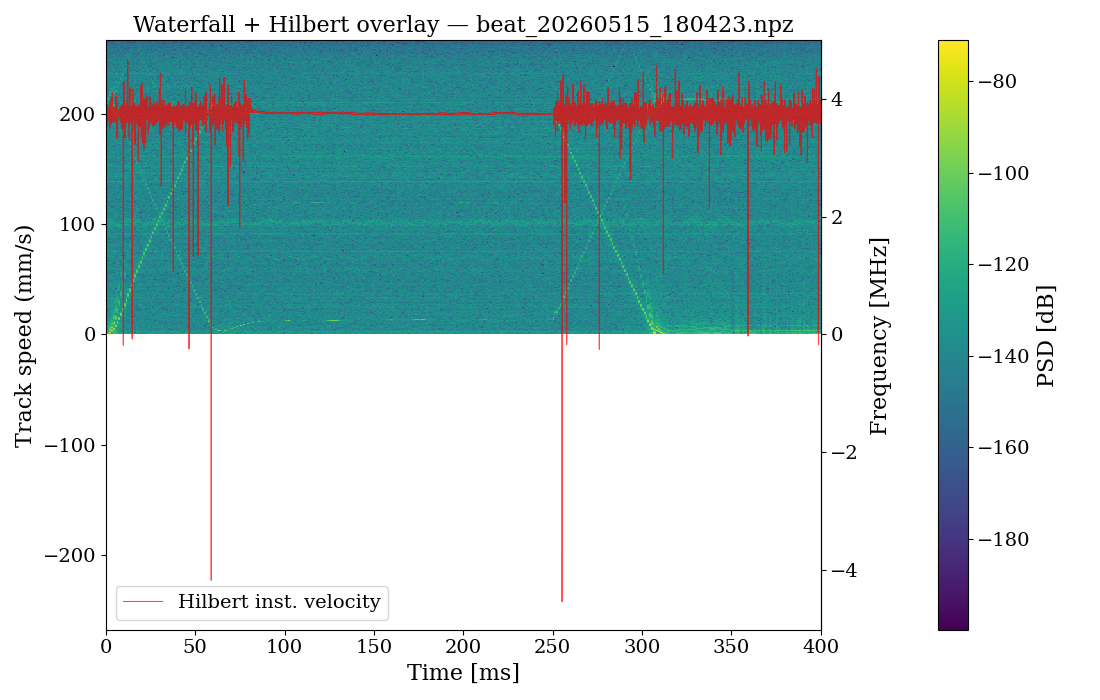

In [16]:
# %% Cell 5 — Waterfall (time x, velocity y) with Hilbert instantaneous velocity overlaid
fig5, ax5 = plt.subplots(figsize=(11, 7))

# Convert frequency bins to velocity (mm/s) for the primary y-axis
vels_mm = f_to_v(freqs) * 1e3   # mm/s

im = ax5.pcolormesh(
    seg_times * 1e3,
    vels_mm,
    spec_db.T,
    shading="auto",
    cmap="viridis",
)

# Overlay Hilbert instantaneous velocity (mm/s) vs time (ms)
v_inst_mm = f_to_v(f_inst_s) * 1e3   # Hz -> mm/s
ax5.plot(
    t_cut[::DECIM] * 1e3,
    v_inst_mm[::DECIM],
    color="red",
    lw=0.8,
    alpha=0.7,
    label="Hilbert inst. velocity",
)

ax5.set_xlabel("Time [ms]")
ax5.set_ylabel("Track speed (mm/s)")
ax5.set_title(f"Waterfall + Hilbert overlay — {fname.name}")
ax5.legend(loc="best")

# Secondary y-axis: frequency in MHz on the right
secax = ax5.secondary_yaxis(
    "right",
    functions=(
        lambda v_mm: v_to_f(v_mm * 1e-3) / 1e6,   # mm/s -> MHz
        lambda f_mhz: f_to_v(f_mhz * 1e6) * 1e3,  # MHz -> mm/s
    ),
)
secax.set_ylabel("Frequency [MHz]", labelpad=8)

# Colorbar with padding so it clears the secondary axis
cbar = fig5.colorbar(im, ax=ax5, label="PSD [dB]", pad=0.12)

# Clip y-axis to the band of interest (convert F_HI to mm/s)
#ax5.set_ylim(65, 75)

plt.tight_layout()
plt.show()  

In [57]:
# %% Cell 5 — Batch process all files, store decimated results
from scipy.signal import butter, sosfiltfilt, hilbert
from scipy.ndimage import uniform_filter1d
import gc, hashlib, json

# ---- File selection ----
data_dir = Path("~/eedm_jml/daqAnalysisAndExperiments/launch/measureTrackVelocityBeatNote/data_gitignore/300mmps_2026_may_26").expanduser()

# Set BATCH_FILES to None (or []) to use all .npz in data_dir.
# Otherwise: list of filenames (str) or Paths. Bare names are resolved against data_dir.
BATCH_FILES = None
# BATCH_FILES = [
#     "run_001.npz",
#     "run_005.npz",
# ]

if not BATCH_FILES:
    batch_files = sorted(data_dir.glob("*.npz"))
else:
    batch_files = [Path(f) if Path(f).is_absolute() else data_dir / f for f in BATCH_FILES]
    missing = [p for p in batch_files if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Missing files: {[p.name for p in missing]}")

# ---- Params (change these to invalidate cache) ----
BATCH_PARAMS = dict(
    t_start   = 100e-3,
    t_end     = 275e-3,
    F_LO      = 3.7e6*300/200,
    F_HI      = 3.8e6*300/200,
    ORDER     = 4,
    SMOOTH_MS = 0.5,
    N_OUT     = 100_000,   # decimated points per file
)
FORCE_REPROCESS = False

# Hash params so cached entries auto-invalidate when you tweak settings
_param_hash = hashlib.md5(json.dumps(BATCH_PARAMS, sort_keys=True).encode()).hexdigest()[:8]

# Persistent results dict across cell re-runs
try:
    RESULTS
except NameError:
    RESULTS = {}

data_der = './data/10shots_2026_may_15'
batch_files = sorted(data_dir.glob("*.npz"))
print(f"Found {len(batch_files)} files. Param hash: {_param_hash}")

def _process_one(path, P):
    d = np.load(path, allow_pickle=True, mmap_mode="r")
    t  = d["times"]
    v  = d["voltages"]
    fs = float(d["sample_rate"])
    xinc = 1.0 / fs

    # Cut
    t_start = max(P["t_start"], float(t[0]))
    t_end   = min(P["t_end"],   float(t[-1]))
    i0 = np.searchsorted(t, t_start)
    i1 = np.searchsorted(t, t_end)
    # Force a real (non-mmap) copy of just the slice we need
    v_cut = np.array(v[i0:i1], dtype=np.float64)
    t0    = float(t[i0])
    n     = len(v_cut)
    del d, t, v

    # Bandpass (sos is more stable than ba for narrow bands)
    nyq = fs / 2
    sos = butter(P["ORDER"], [P["F_LO"]/nyq, P["F_HI"]/nyq], btype="band", output="sos")
    v_filt = sosfiltfilt(sos, v_cut)
    del v_cut

    # Analytic signal
    analytic = hilbert(v_filt)
    del v_filt
    envelope = np.abs(analytic)
    phase    = np.unwrap(np.angle(analytic))
    del analytic

    f_inst = np.gradient(phase, xinc)/(2*np.pi)
    del phase

    # Smooth
    nsmooth = max(1, int(round(P["SMOOTH_MS"]*1e-3*fs)))
    if nsmooth > 1:
        f_inst   = uniform_filter1d(f_inst,   size=nsmooth, mode="nearest")
        envelope = uniform_filter1d(envelope, size=nsmooth, mode="nearest")

    # Decimate (stride; uniform smoothing already acted as anti-alias)
    decim = max(1, n // P["N_OUT"])
    sl = slice(None, None, decim)
    t_ms       = (t0 + np.arange(n, dtype=np.float64)[sl]*xinc) * 1e3
    f_inst_d   = f_inst[sl].astype(np.float32)
    envelope_d = envelope[sl].astype(np.float32)
    v_track_d  = (f_to_v(f_inst_d) * 1e3).astype(np.float32)   # mm/s

    return {
        "t_ms":         t_ms.astype(np.float32),
        "f_inst_Hz":    f_inst_d,
        "envelope_mV":  envelope_d * 1e3,
        "v_track_mms":  v_track_d,
        "fs":           fs,
        "n_raw":        n,
        "decim":        decim,
        "param_hash":   _param_hash,
    }

import time
for k, path in enumerate(batch_files):
    name = path.name
    cached = RESULTS.get(name)
    if (cached is not None
        and cached.get("param_hash") == _param_hash
        and not FORCE_REPROCESS):
        print(f"[{k+1:3d}/{len(batch_files)}] cached  {name}")
        continue
    t0 = time.time()
    try:
        RESULTS[name] = _process_one(path, BATCH_PARAMS)
    except Exception as e:
        print(f"[{k+1:3d}/{len(batch_files)}] FAILED  {name}: {e}")
        continue
    dt = time.time() - t0
    print(f"[{k+1:3d}/{len(batch_files)}] done    {name}  ({dt:.1f}s, "
          f"{RESULTS[name]['n_raw']/1e6:.1f} M pts -> {len(RESULTS[name]['t_ms'])/1e3:.0f} k)")
    gc.collect()

# Drop stale entries (params changed, files removed)
_present = {p.name for p in batch_files}
for k in list(RESULTS):
    if k not in _present or RESULTS[k].get("param_hash") != _param_hash:
        del RESULTS[k]

mem_mb = sum(r["t_ms"].nbytes + r["f_inst_Hz"].nbytes
             + r["envelope_mV"].nbytes + r["v_track_mms"].nbytes
             for r in RESULTS.values()) / 1e6
print(f"\nRESULTS holds {len(RESULTS)} files, ~{mem_mb:.1f} MB in memory")

Found 11 files. Param hash: 8d9a4343
[  1/11] done    beat_20260526_160124.npz  (1.9s, 8.8 M pts -> 101 k)
[  2/11] done    beat_20260526_160229.npz  (1.6s, 8.8 M pts -> 101 k)
[  3/11] done    beat_20260526_160327.npz  (1.5s, 8.8 M pts -> 101 k)
[  4/11] done    beat_20260526_160349.npz  (1.5s, 8.8 M pts -> 101 k)
[  5/11] done    beat_20260526_160408.npz  (1.5s, 8.8 M pts -> 101 k)
[  6/11] done    beat_20260526_160428.npz  (1.6s, 8.8 M pts -> 101 k)
[  7/11] done    beat_20260526_160459.npz  (1.5s, 8.8 M pts -> 101 k)
[  8/11] done    beat_20260526_160522.npz  (1.5s, 8.8 M pts -> 101 k)
[  9/11] done    beat_20260526_160551.npz  (1.5s, 8.8 M pts -> 101 k)
[ 10/11] done    beat_20260526_160612.npz  (1.5s, 8.8 M pts -> 101 k)
[ 11/11] done    beat_20260526_160638.npz  (1.5s, 8.8 M pts -> 101 k)

RESULTS holds 11 files, ~17.7 MB in memory


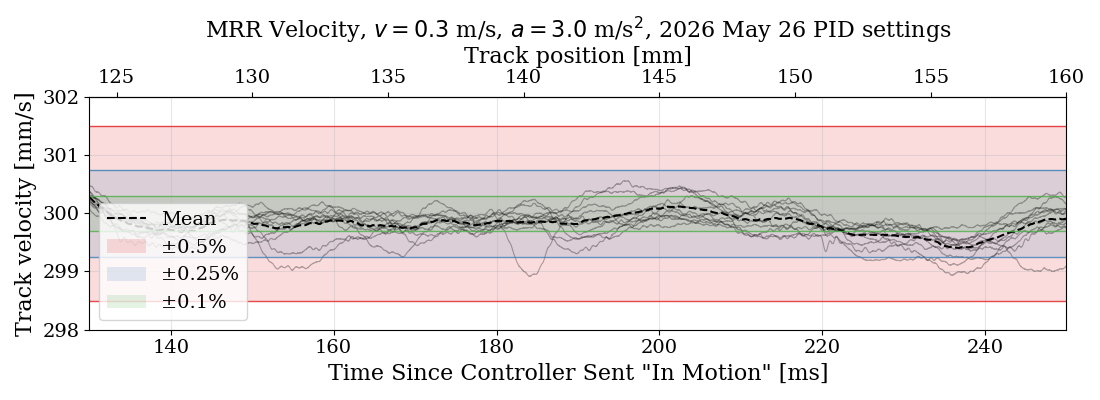

In [59]:
# %% Cell 6 — Plot all velocities + mean + tolerance bands (no reprocessing)
plt.close('all')

TOL_CENTER = 300             # mm/s
TOL_PCTS   = [0.1, 0.25, 0.5]   # ± percents of TOL_CENTER
TOL_CMAP   = "Set1"             # distinct colors per tolerance
SHADE_ALPHA = 0.15
LINE_ALPHA  = 0.8
LINE_LW     = 1.0

fig, ax = plt.subplots(figsize=(11, 4))

for name, r in RESULTS.items():
    ax.plot(r["t_ms"], r["v_track_mms"], color = 'k', lw=.8, alpha=0.3)

# Mean across files (assumes identical time grids)
names = list(RESULTS)
t_ref = RESULTS[names[0]]["t_ms"]
stack = np.stack([RESULTS[n]["v_track_mms"] for n in names])
mean  = stack.mean(axis=0)
ax.plot(t_ref, mean, '--', color="k", lw=1.5, label=f"Mean")

# Tolerance bands (sorted widest -> narrowest so narrow ones aren't hidden)
tol_cmap = plt.get_cmap(TOL_CMAP)
sorted_pcts = sorted(TOL_PCTS, reverse=True)
for i, pct in enumerate(sorted_pcts):
    tol = TOL_CENTER * pct / 100
    color = tol_cmap(i)
    ax.axhspan(TOL_CENTER - tol, TOL_CENTER + tol,
               color=color, alpha=SHADE_ALPHA, lw=0,
               label=f"±{pct:g}%")
    ax.axhline(TOL_CENTER + tol, color=color, lw=LINE_LW, alpha=LINE_ALPHA)
    ax.axhline(TOL_CENTER - tol, color=color, lw=LINE_LW, alpha=LINE_ALPHA)

#set top axis position
# ---- Top axis: track position from kinematics ----
X0      = 100.0     # mm, position at t=0
VF      = 300.0      # mm/s, coast velocity
ACCEL   = 3000.0    # mm/s^2, acceleration during ramp
POS_UNIT = "mm"

t_ramp = VF / ACCEL if ACCEL > 0 else 0.0           # s
x_ramp = X0 + 0.5 * ACCEL * t_ramp**2               # mm

def t_ms_to_x(t_ms, x0=X0, vf=VF, a=ACCEL, t_r=t_ramp, x_r=x_ramp):
    t = np.asarray(t_ms, dtype=float) * 1e-3
    return np.where(
        t <= t_r,
        x0 + 0.5 * a * t**2,
        x_r + vf * (t - t_r),
    )

def x_to_t_ms(x, x0=X0, vf=VF, a=ACCEL, t_r=t_ramp, x_r=x_ramp):
    x = np.asarray(x, dtype=float)
    t = np.where(
        x <= x_r,
        np.sqrt(np.maximum(2 * (x - x0) / a, 0)) if a > 0 else (x - x0) / vf,
        t_r + (x - x_r) / vf,
    )
    return t * 1e3

topax = ax.secondary_xaxis("top", functions=(t_ms_to_x, x_to_t_ms))
topax.set_xlabel(f"Track position [{POS_UNIT}]")


ax.set_xlabel('Time Since Controller Sent "In Motion" [ms]')
ax.set_ylabel("Track velocity [mm/s]")
ax.grid(True, alpha=0.3)
ax.set_xlim(130, 250)
ax.set_ylim(298, 302)
if len(RESULTS) <= 12:
    ax.legend(loc="lower left")
plt.title(rf'MRR Velocity, $v = {VF/1000}$ m/s, $a = {ACCEL/1000}$ m/s$^2$, 2026 May 26 PID settings')
fig.tight_layout(); plt.show()


In [ ]:
# %% Cell 6 — Offset-stacked time series with y-axis + grid
plt.close('all')
from matplotlib.ticker import MultipleLocator

# ---- Display params ----
X_LIM = (75, 250)
Y_LIM = (-1, 2)              # mm/s, per-curve range around its offset
V_SUBTRACT = 200.0           # mm/s, constant subtracted from every curve
V_DISPLAY_OFFSET = 1        # mm/s between curves
X_GRID_SPACING = 10.0        # ms
Y_GRID_SPACING = 1.0         # mm/s
CMAP = "viridis"

cmap = plt.get_cmap(CMAP)
names = list(RESULTS.keys())
n = len(names)

fig, ax = plt.subplots(figsize=(11, max(4, 0.4*n + 2)))

x0, x1 = X_LIM

for i, name in enumerate(names):
    r = RESULTS[name]
    t = r["t_ms"]
    i0 = np.searchsorted(t, x0)
    i1 = np.searchsorted(t, x1)
    tt = t[i0:i1]
    vv = r["v_track_mms"][i0:i1] - V_SUBTRACT

    offset = i * V_DISPLAY_OFFSET
    color = cmap(i / max(n - 1, 1))
    ax.plot(tt, vv + offset, lw=0.5, color=color)

ax.set_xlim(X_LIM)
ax.set_ylim(Y_LIM[0], (n - 1) * V_DISPLAY_OFFSET + Y_LIM[1])
ax.set_xlabel("Time (ms)")
ax.set_ylabel(f"Track velocity − {V_SUBTRACT:g} mm/s  (offset {V_DISPLAY_OFFSET:g} mm/s per curve)")

# ---- Grid ----
ax.xaxis.set_major_locator(MultipleLocator(X_GRID_SPACING))
ax.yaxis.set_major_locator(MultipleLocator(Y_GRID_SPACING))
ax.grid(True, which="major", alpha=0.3)

fig.tight_layout()
plt.show()

In [ ]:
# %% Cell 7 — Mean ± 1σ across files (assumes identical time grids)
plt.close('all')
from matplotlib.ticker import MultipleLocator

# ---- Display params ----
X_LIM = (50, 250)
Y_LIM = (-3, 3)              # mm/s, around V_SUBTRACT
V_SUBTRACT = 200.0           # mm/s
X_GRID_SPACING = 10.0        # ms
Y_GRID_SPACING = 1.0         # mm/s
N_SIGMA = 1.0

names = list(RESULTS.keys())
n = len(names)

# Sanity check: all grids identical
t_ref = RESULTS[names[0]]["t_ms"]
for name in names[1:]:
    t = RESULTS[name]["t_ms"]
    if t.shape != t_ref.shape or not np.array_equal(t, t_ref):
        raise ValueError(f"Time grid mismatch in {name}; reprocess with identical params.")

# Crop to view window
m = (t_ref >= X_LIM[0]) & (t_ref <= X_LIM[1])
t_common = t_ref[m]

# Stack
stack = np.stack([RESULTS[name]["v_track_mms"][m] for name in names]) - V_SUBTRACT

mean = stack.mean(axis=0)
std  = stack.std(axis=0, ddof=1) if n > 1 else np.zeros_like(mean)

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(t_common, mean - N_SIGMA*std, mean + N_SIGMA*std,
                color="C0", alpha=0.25, lw=0, label=f"±{N_SIGMA:g}σ (n={n})")
ax.plot(t_common, mean, color="C0", lw=0.8, label="mean")

ax.set_xlim(X_LIM)
ax.set_ylim(Y_LIM)
ax.set_xlabel("Time (ms)")
ax.set_ylabel(f"Track velocity − {V_SUBTRACT:g} mm/s")
ax.xaxis.set_major_locator(MultipleLocator(X_GRID_SPACING))
ax.yaxis.set_major_locator(MultipleLocator(Y_GRID_SPACING))
ax.grid(True, which="major", alpha=0.3)
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

print(f"n = {n} shots, {t_common.size} points")
print(f"mean σ(t): {std.mean():.3f} mm/s    max σ(t): {std.max():.3f} mm/s")